# Lab 8 – Visualization of Text Data

This lab covers five core techniques for visualising textual information:
1. **Word Clouds** – visual frequency maps of words
2. **Named Entity Recognition (NER)** – entity highlighting with spaCy
3. **Sentiment Analysis** – polarity & subjectivity visualisations
4. **Word Frequency Analysis** – most common terms
5. **N-gram Analysis** – common bigrams and trigrams

## Part 1 – Word Clouds

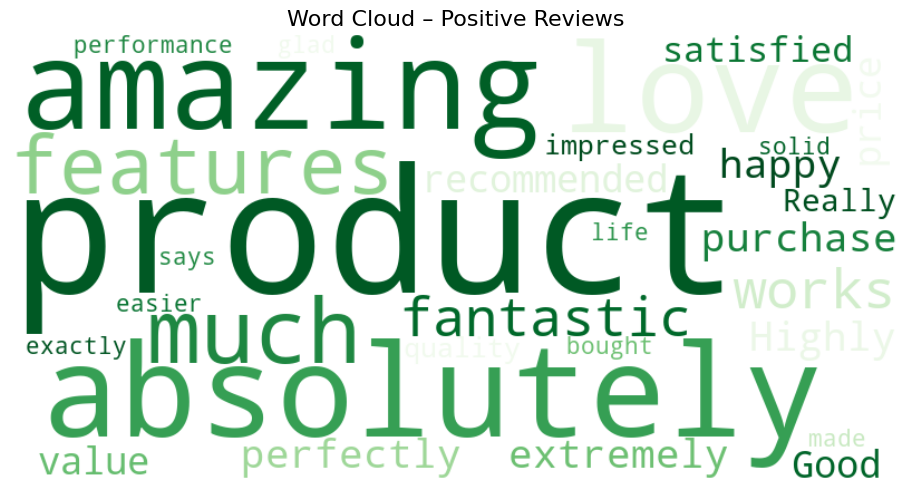

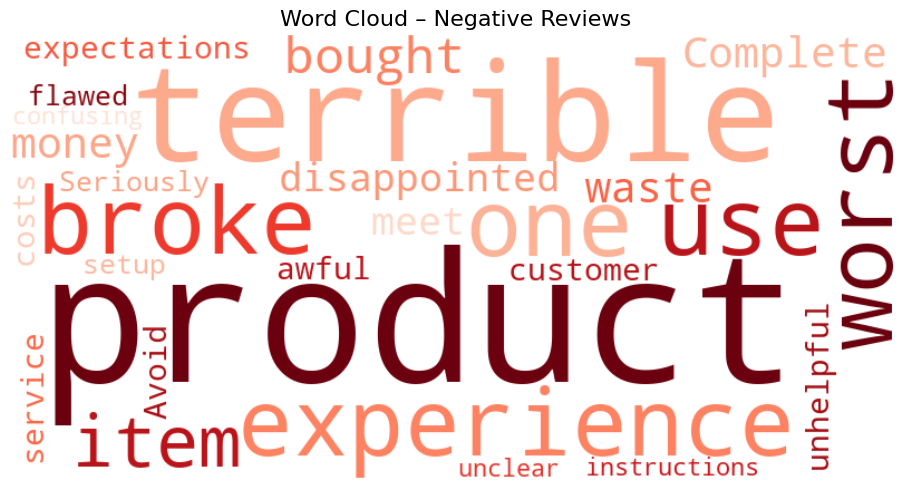

Word clouds saved.


In [1]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from textblob import TextBlob

# Sample product reviews with ground-truth sentiment labels
reviews_with_sentiment = [
    ("This product is absolutely amazing! I love it so much.", "positive"),
    ("The features are fantastic and it works perfectly.", "positive"),
    ("I am extremely happy with this purchase. Highly recommended!", "positive"),
    ("What a terrible experience. The product broke after just one use.", "negative"),
    ("This is the worst item I have ever bought. Complete waste of money.", "negative"),
    ("I was so disappointed. It didn't meet my expectations at all.", "negative"),
    ("It's okay, but nothing special. Could be better.", "neutral"),
    ("Good value for the price. I'm satisfied.", "positive"),
    ("The customer service was awful and unhelpful.", "negative"),
    ("Really impressed with the quality and performance!", "positive"),
    ("Meh, it's alright. Not great, not bad.", "neutral"),
    ("Avoid this product at all costs! Seriously flawed.", "negative"),
    ("So glad I bought this! It has made my life easier.", "positive"),
    ("The setup was confusing and the instructions were unclear.", "negative"),
    ("A solid product that does exactly what it says.", "positive"),
]

positive_text = " ".join(r for r, s in reviews_with_sentiment if s == "positive")
negative_text = " ".join(r for r, s in reviews_with_sentiment if s == "negative")
stopwords = set(STOPWORDS)

# --- Positive Word Cloud ---
positive_wc = WordCloud(width=800, height=400, background_color="white",
                        stopwords=stopwords, colormap="Greens",
                        min_font_size=10).generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(positive_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Positive Reviews", fontsize=16)
plt.tight_layout()
plt.savefig("lab8_wordcloud_positive.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Negative Word Cloud ---
negative_wc = WordCloud(width=800, height=400, background_color="white",
                        stopwords=stopwords, colormap="Reds",
                        min_font_size=10).generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(negative_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Negative Reviews", fontsize=16)
plt.tight_layout()
plt.savefig("lab8_wordcloud_negative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word clouds saved.")

## Part 2 – Named Entity Recognition (NER) with spaCy

spaCy's `displacy` renderer highlights named entities (people, organisations, locations, monetary values, dates) inline in the notebook.

In [2]:
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

# --- Single sentence ---
text = "Apple is looking at buying U.K. startup for $1 billion."
doc = nlp(text)
print("Entities in:", text)
displacy.render(doc, style="ent", jupyter=True)

# --- Multiple sentences with richer entity types ---
sentences = [
    "Elon Musk founded SpaceX in 2002 and later acquired Twitter for $44 billion.",
    "The Eiffel Tower in Paris attracts over 7 million visitors per year.",
    "Barack Obama served as the 44th President of the United States from 2009 to 2017.",
    "Google LLC is headquartered in Mountain View, California, founded by Larry Page and Sergey Brin.",
]
for sent in sentences:
    doc = nlp(sent)
    print(f'\n"{sent}"')
    displacy.render(doc, style="ent", jupyter=True)

Entities in: Apple is looking at buying U.K. startup for $1 billion.



"Elon Musk founded SpaceX in 2002 and later acquired Twitter for $44 billion."



"The Eiffel Tower in Paris attracts over 7 million visitors per year."



"Barack Obama served as the 44th President of the United States from 2009 to 2017."



"Google LLC is headquartered in Mountain View, California, founded by Larry Page and Sergey Brin."


## Part 3 – Sentiment Analysis Visualisation

TextBlob gives each text a **polarity** (−1 very negative → +1 very positive) and **subjectivity** (0 objective → 1 subjective) score.

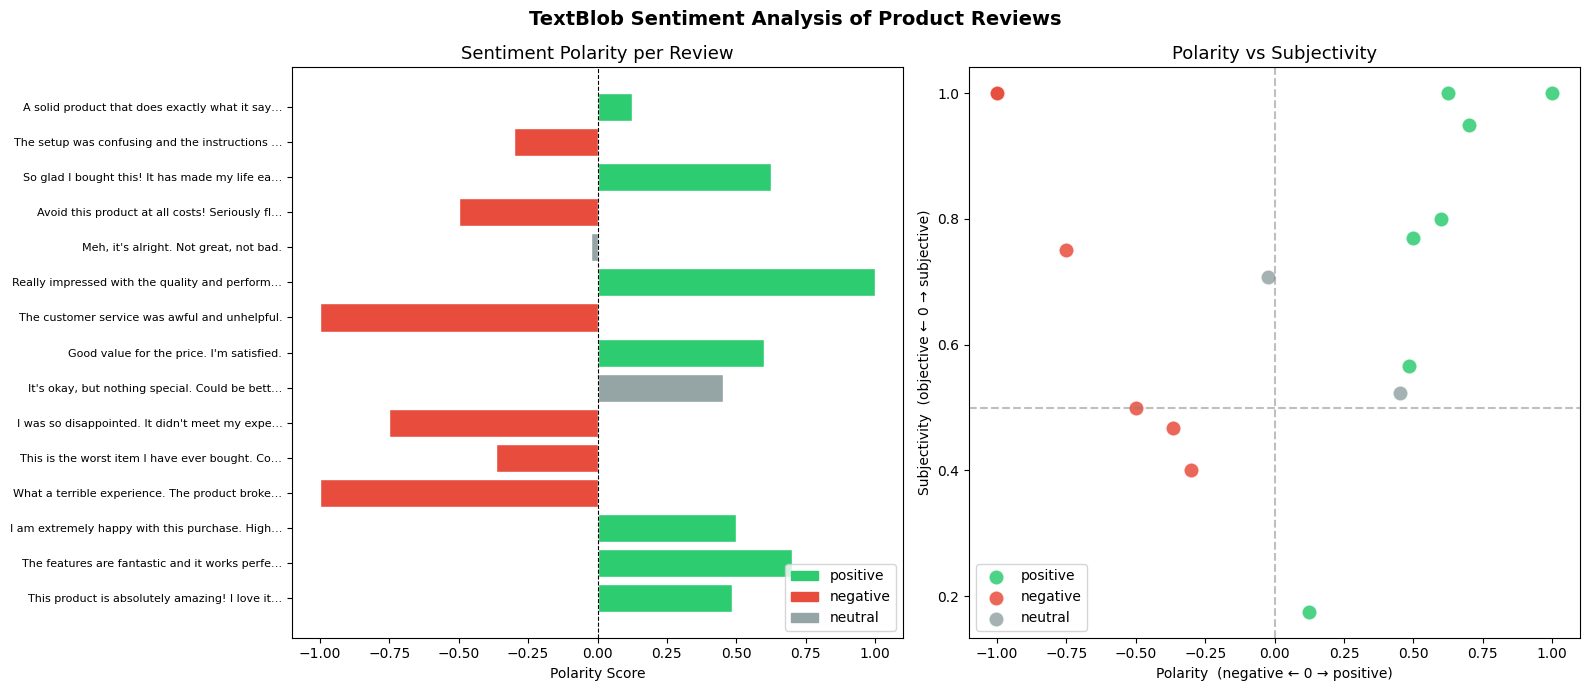

Sentiment analysis chart saved.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

records = []
for review, true_sentiment in reviews_with_sentiment:
    from textblob import TextBlob
    blob = TextBlob(review)
    records.append({
        "label":        (review[:45] + "…") if len(review) > 45 else review,
        "polarity":     blob.sentiment.polarity,
        "subjectivity": blob.sentiment.subjectivity,
        "sentiment":    true_sentiment,
    })

df = pd.DataFrame(records)
color_map = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
colors = [color_map[s] for s in df["sentiment"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Horizontal bar: polarity per review
axes[0].barh(df["label"], df["polarity"], color=colors, edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Polarity Score")
axes[0].set_title("Sentiment Polarity per Review", fontsize=13)
axes[0].tick_params(axis="y", labelsize=8)
legend_handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
axes[0].legend(handles=legend_handles, loc="lower right")

# Scatter: polarity vs subjectivity
for sentiment, color in color_map.items():
    mask = df["sentiment"] == sentiment
    axes[1].scatter(df[mask]["polarity"], df[mask]["subjectivity"],
                    c=color, label=sentiment, s=120, alpha=0.85, edgecolors="white")
axes[1].axvline(0,   color="gray", linestyle="--", alpha=0.5)
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Polarity  (negative ← 0 → positive)")
axes[1].set_ylabel("Subjectivity  (objective ← 0 → subjective)")
axes[1].set_title("Polarity vs Subjectivity", fontsize=13)
axes[1].legend()

plt.suptitle("TextBlob Sentiment Analysis of Product Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lab8_sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sentiment analysis chart saved.")

## Part 4 – Word Frequency Analysis

Counting the most frequent tokens (after removing stopwords) shows which words dominate the corpus.

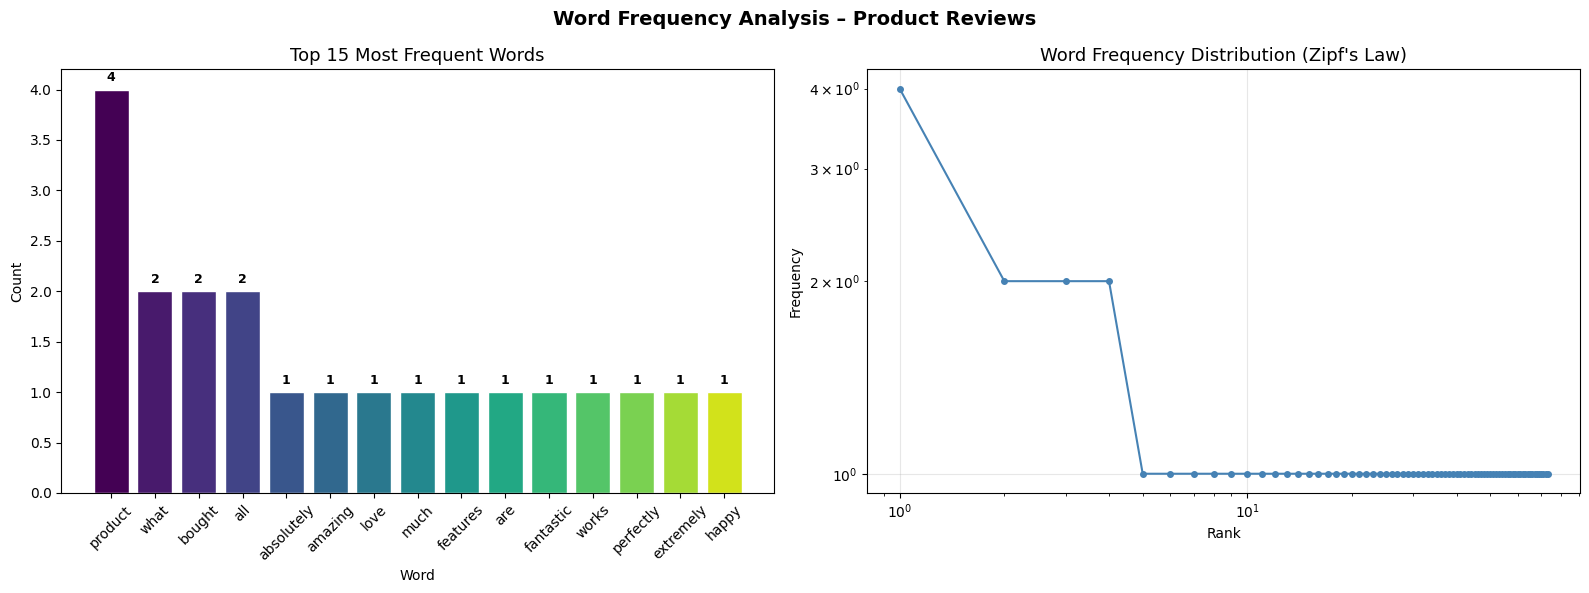

Word frequency chart saved.


In [4]:
import re
from collections import Counter
import matplotlib.pyplot as plt

CUSTOM_STOPWORDS = {
    "the", "it", "is", "and", "a", "i", "my", "so", "this",
    "was", "for", "not", "with", "me", "its", "but", "has",
    "be", "to", "that", "at", "an", "of", "in", "have",
}

def tokenize(text, stopwords=None):
    tokens = re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())
    return [t for t in tokens if not stopwords or t not in stopwords]

all_text = " ".join(r for r, _ in reviews_with_sentiment)
tokens   = tokenize(all_text, CUSTOM_STOPWORDS)
freq     = Counter(tokens)

top_n = 15
words, counts = zip(*freq.most_common(top_n))
palette = plt.cm.viridis([i / top_n for i in range(top_n)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart – top N words
bars = axes[0].bar(words, counts, color=palette, edgecolor="white")
axes[0].set_xlabel("Word")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Top {top_n} Most Frequent Words", fontsize=13)
axes[0].tick_params(axis="x", rotation=45)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")

# Log-log frequency distribution (Zipf's law)
sorted_counts = sorted(freq.values(), reverse=True)
axes[1].plot(range(1, len(sorted_counts) + 1), sorted_counts,
             marker="o", markersize=4, color="steelblue")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Word Frequency Distribution (Zipf's Law)", fontsize=13)
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Word Frequency Analysis – Product Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lab8_word_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Word frequency chart saved.")

## Part 5 – N-gram Analysis

N-grams are contiguous sequences of *n* words. Bigrams (n=2) and trigrams (n=3) reveal common multi-word phrases that single-word frequency cannot capture.

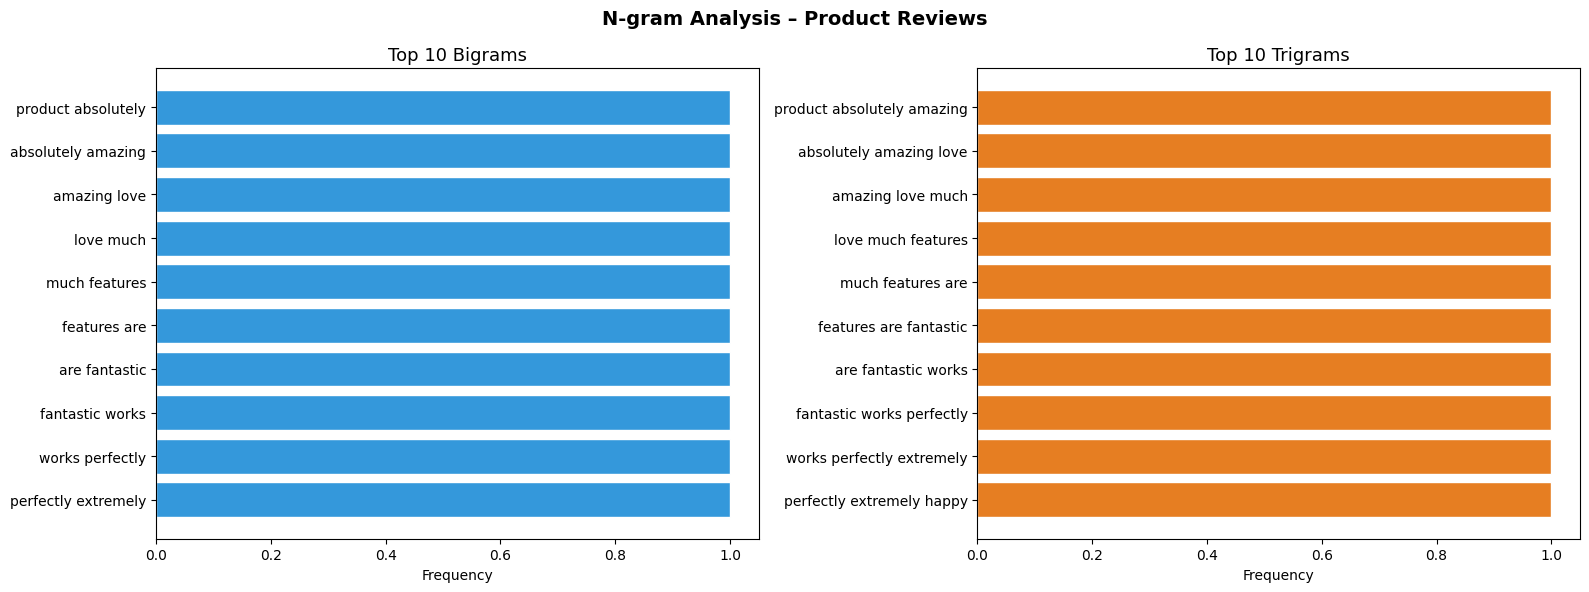

N-gram chart saved.


In [5]:
from collections import Counter
import matplotlib.pyplot as plt

def get_ngrams(token_list, n):
    return [tuple(token_list[i:i+n]) for i in range(len(token_list) - n + 1)]

# Reuse tokens computed in Part 4
bigrams  = get_ngrams(tokens, 2)
trigrams = get_ngrams(tokens, 3)

top_bg = Counter(bigrams).most_common(10)
top_tg = Counter(trigrams).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bg_labels = [" ".join(bg) for bg, _ in top_bg]
bg_counts = [c for _, c in top_bg]
axes[0].barh(bg_labels[::-1], bg_counts[::-1], color="#3498db", edgecolor="white")
axes[0].set_xlabel("Frequency")
axes[0].set_title("Top 10 Bigrams", fontsize=13)

tg_labels = [" ".join(tg) for tg, _ in top_tg]
tg_counts = [c for _, c in top_tg]
axes[1].barh(tg_labels[::-1], tg_counts[::-1], color="#e67e22", edgecolor="white")
axes[1].set_xlabel("Frequency")
axes[1].set_title("Top 10 Trigrams", fontsize=13)

plt.suptitle("N-gram Analysis – Product Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lab8_ngrams.png", dpi=150, bbox_inches="tight")
plt.show()
print("N-gram chart saved.")